In [53]:
#import necessary libraries

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Data handling and Linear algebra
import pandas as pd
import numpy as np

#Manipulating data and Model building
import tensorflow as tf

#Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [54]:
url = "https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv"
data = pd.read_csv(url, sep=';', header=None,
                   names=['year', 'month', 'decimal_year', 'sunspot_number', 
                          'std_dev', 'observations', 'indicator'])
data.head()

,year,month,decimal_year,sunspot_number,std_dev,observations,indicator
0,1749,1,1749.042,96.7,-1.0,-1,1
1,1749,2,1749.123,104.3,-1.0,-1,1
2,1749,3,1749.204,116.7,-1.0,-1,1
3,1749,4,1749.288,92.8,-1.0,-1,1
4,1749,5,1749.371,141.7,-1.0,-1,1


In [55]:
data.tail()

,year,month,decimal_year,sunspot_number,std_dev,observations,indicator
3323,2025,12,2025.958,124.2,21.3,736,1
3324,2026,1,2026.042,112.5,22.1,666,0
3325,2026,2,2026.122,78.2,14.2,757,0
3326,2026,3,2026.204,85.9,12.7,1202,0
3327,2026,4,2026.286,79.3,11.4,1159,0


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3328 entries, 0 to 3327
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            3328 non-null   int64  
 1   month           3328 non-null   int64  
 2   decimal_year    3328 non-null   float64
 3   sunspot_number  3328 non-null   float64
 4   std_dev         3328 non-null   float64
 5   observations    3328 non-null   int64  
 6   indicator       3328 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 182.1 KB


In [57]:
#Last column--> Sunspots data
sunspots = data.iloc[:,3]
sunspots.values

array([ 96.7, 104.3, 116.7, ...,  78.2,  85.9,  79.3])

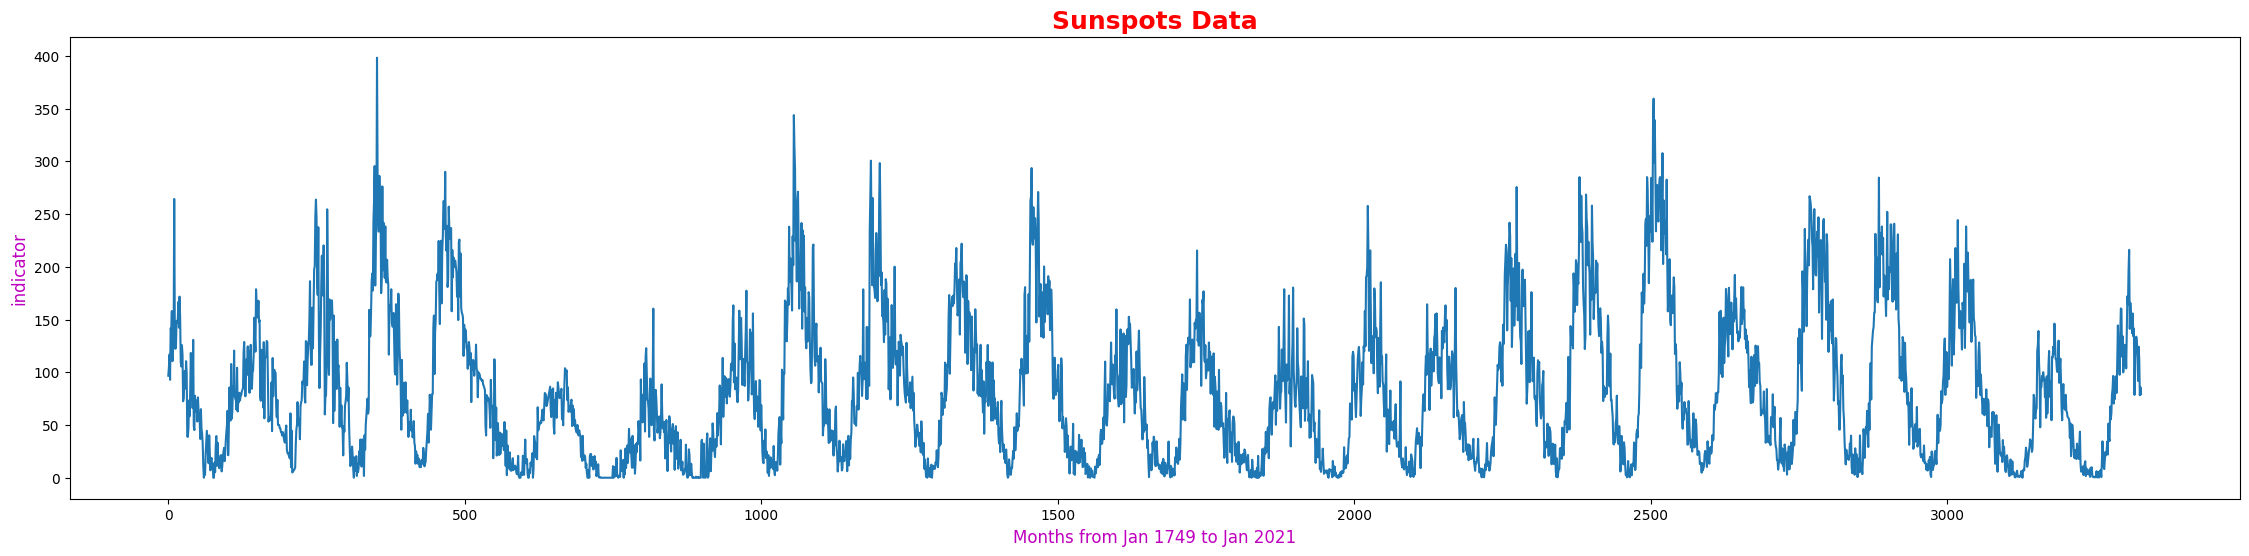

In [58]:
#Visualize the data
plt.figure(figsize=(28,6))
plt.plot(sunspots)
plt.ylabel(data.columns[-1],fontsize=12,color='m')
plt.xlabel("Months from Jan 1749 to Jan 2021",fontsize=12,color='m')
plt.title("Sunspots Data",fontsize=18,color='r',weight='bold')
plt.show()

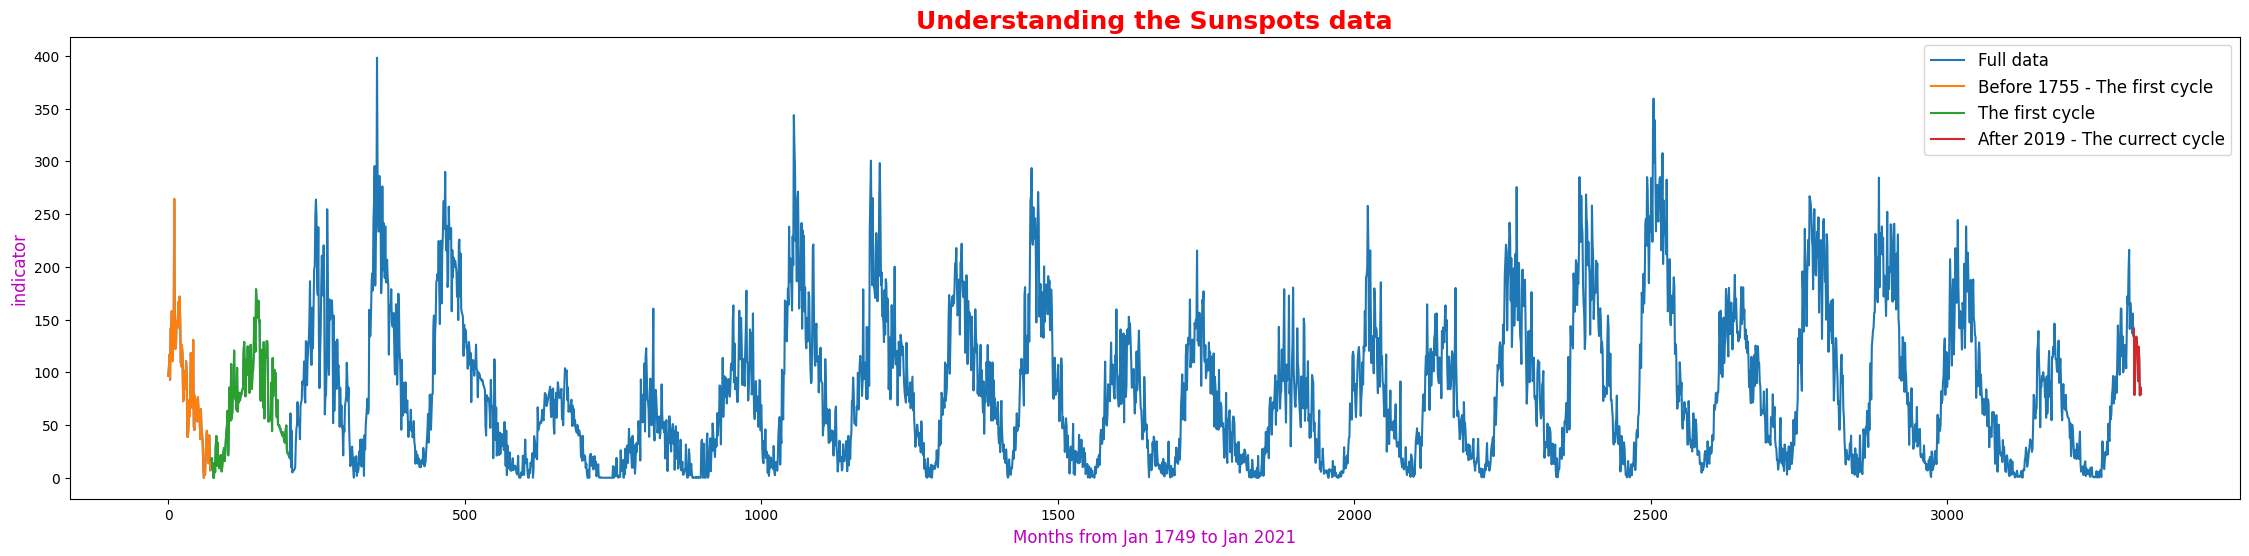

In [59]:
'''Approx 11 years cycle ---> approx 132 months cycle'''
plt.figure(figsize=(28,6))
plt.plot(sunspots)            # The whole data
plt.plot(sunspots[:72])       # Data from 1749, actual cycles started from 1755 --> 6 years means 72 months
plt.plot(sunspots[72:72+132]) # Showing the first cycle
plt.plot(sunspots[-13:])      # Displaying the current cycle
plt.ylabel(data.columns[-1], fontsize = 12, color = 'm')
plt.xlabel("Months from Jan 1749 to Jan 2021", fontsize = 12, color = 'm')
plt.title("Understanding the Sunspots data", fontsize = 18, color = 'r', weight = 'bold')
plt.legend(["Full data", "Before 1755 - The first cycle", "The first cycle", "After 2019 - The currect cycle"], fontsize = 12)
plt.show()

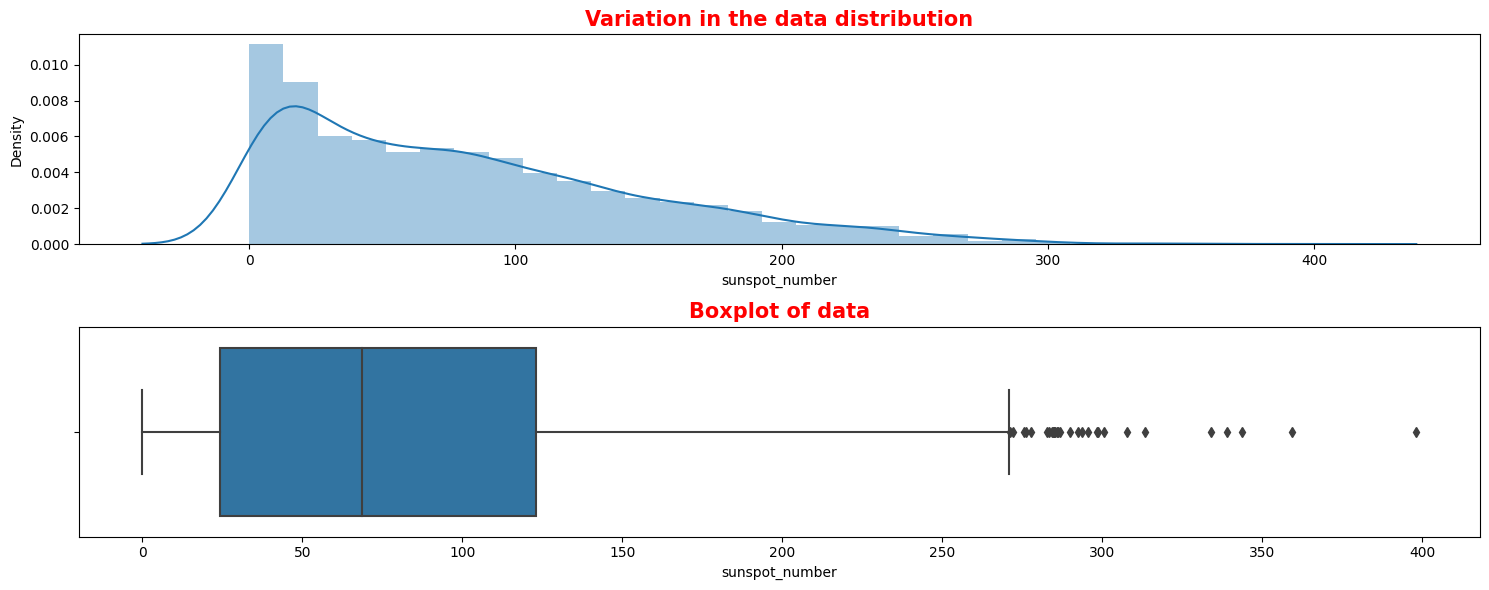

In [60]:
#Visualize the variation in the data distribution along with the outliers in the time series data
plt.figure(figsize=(15,6))
plt.subplot(2,1,1)
sns.distplot(sunspots)
plt.title("Variation in the data distribution",fontsize=15,color='r',weight='bold')
plt.subplot(2,1,2)
sns.boxplot(x=sunspots)
plt.title("Boxplot of data",fontsize=15,color='r',weight='bold')
plt.tight_layout()
plt.show()

In [61]:
#Helper function: Training data generation
def windowed_dataset(series, window_size, batch_size, shuffle_buffer):
    series = series[:, np.newaxis]                                # Adding new dimension to the series array in the position where np.newaxis is written
    ds = tf.data.Dataset.from_tensor_slices(series)               # In order to use window of tensorflow convert numpy array to tensor
    ds = ds.window(window_size + 1, shift=1, drop_remainder=True) # Creating window for generating sequence (yet not seperating it with the future values) - LSTM
    ds = ds.flat_map(lambda w: w.batch(window_size + 1))          # Flatten a dataset of batches into a dataset of their elements
    ds = ds.shuffle(shuffle_buffer)                               # To reduce the variance and making sure that the model remain general and less overfits
    ds = ds.map(lambda w: (w[:-1], w[-1]))                        # In a window, last value is the future value that our model needs to learn and predict while testing it
    return ds.batch(batch_size).prefetch(1)                       # Prefetch one batch of data and make sure that there is always one ready


In [62]:
# Forecast would work in the same way where we provide the sequence and the output will be predicted by the model
def model_forecast(model, series, window_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size))
    ds = ds.batch(batch_size).prefetch(1)
    forecast = model.predict(ds)  # To predict
    return forecast

In [63]:
# Preparing the data
series = data['sunspot_number'].values
time = data.index.values 

# Splitting the data into train and test
split_time = int(len(series)*0.9)          # 90% of the original data is for training
time_train = time[:split_time]
x_train = series[:split_time]
time_valid = time[split_time:]
x_valid = series[split_time:]
print(f"There are {len(x_train)} training samples and {len(x_valid)} validation samples.")

# Parameters
delta = 1                      # Huber loss
window_size = 60               # For dataset
batch_size = 145               # For dataset
shuffle_buffer_size= 900       # Shuffling the dataset randomly
epochs = 100                   # For optimal learning rate
train_epochs = epochs + 100    # Training epochs
momentum_sgd = 0.9             # For optimizer

There are 2995 training samples and 333 validation samples.


In [64]:
# To avoid clutter from old models and layers (in case of re-running the notebook without reset and resestart)
tf.keras.backend.clear_session()

# To produce same sequence of results each time the code runs
tf.random.set_seed(42)
np.random.seed(42)

# Calling the window_dataset function to generate the training data
train_set = windowed_dataset(x_train, window_size, batch_size, shuffle_buffer_size)

# Building the model
model = tf.keras.models.Sequential([
  # Conv1D layers smoothens out the input time-series so we don't have to add the rolling mean or rolling standard deviation values in the input features
  tf.keras.layers.Conv1D(filters=132, kernel_size=4,strides=1, padding="causal", activation="relu",input_shape=[None, 1]),
  tf.keras.layers.LSTM(256, return_sequences=True), # Return sequence if set to true will return the outputs for each time step as explained above
  tf.keras.layers.LSTM(132, return_sequences=False),# Setting it as False will only output the last time step which will then be feeded into the fully connected layers
  tf.keras.layers.Dense(80, activation="relu"),
  tf.keras.layers.Dense(10, activation="relu"),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Lambda(lambda x: x * 400)        # To push the values in the range of the original data after getting passed from different activations
])

# Display this model summary
model.summary()

# Using callbacks - Learning rate scheduler to find the optimal value to be used in the final model
lr_schedule = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-8 * 10**(epoch / 20), verbose = 0) # lr --> starting lr * 10^(0/20), starting lr * 10^(1/20), so on..

# Stochastic Gradient Desect as the optimizer
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-8, momentum=momentum_sgd)
model.compile(loss=tf.keras.losses.Huber(delta),
              optimizer=optimizer,
              metrics=["mae"])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, None, 132)         660       
                                                                 
 lstm (LSTM)                 (None, None, 256)         398336    
                                                                 
 lstm_1 (LSTM)               (None, 132)               205392    
                                                                 
 dense (Dense)               (None, 80)                10640     
                                                                 
 dense_1 (Dense)             (None, 10)                810       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
 lambda (Lambda)             (None, 1)                 0

In [65]:
history = model.fit(train_set, epochs=epochs, callbacks=[lr_schedule]) # Track the history of training

Epoch 1/100
21/21 [==============================] - 12s 436ms/step - loss: 87.1931 - mae: 87.6923 - lr: 1.0000e-08
Epoch 2/100
21/21 [==============================] - 11s 508ms/step - loss: 67.4192 - mae: 67.9188 - lr: 1.1220e-08
Epoch 3/100
21/21 [==============================] - 14s 659ms/step - loss: 51.2595 - mae: 51.7579 - lr: 1.2589e-08
Epoch 4/100
21/21 [==============================] - 14s 656ms/step - loss: 44.1954 - mae: 44.6938 - lr: 1.4125e-08
Epoch 5/100
21/21 [==============================] - 14s 673ms/step - loss: 39.0681 - mae: 39.5658 - lr: 1.5849e-08
Epoch 6/100
21/21 [==============================] - 15s 708ms/step - loss: 34.9323 - mae: 35.4295 - lr: 1.7783e-08
Epoch 7/100
21/21 [==============================] - 17s 784ms/step - loss: 31.6378 - mae: 32.1344 - lr: 1.9953e-08
Epoch 8/100
21/21 [==============================] - 14s 662ms/step - loss: 29.0580 - mae: 29.5546 - lr: 2.2387e-08
Epoch 9/100
21/21 [==============================] - 14s 650ms/step - lo

In [66]:
# Learning rates used above
lrs = 1e-8 * (10**(np.arange(epochs)/20))
lrs

array([1.00000000e-08, 1.12201845e-08, 1.25892541e-08, 1.41253754e-08,
       1.58489319e-08, 1.77827941e-08, 1.99526231e-08, 2.23872114e-08,
       2.51188643e-08, 2.81838293e-08, 3.16227766e-08, 3.54813389e-08,
       3.98107171e-08, 4.46683592e-08, 5.01187234e-08, 5.62341325e-08,
       6.30957344e-08, 7.07945784e-08, 7.94328235e-08, 8.91250938e-08,
       1.00000000e-07, 1.12201845e-07, 1.25892541e-07, 1.41253754e-07,
       1.58489319e-07, 1.77827941e-07, 1.99526231e-07, 2.23872114e-07,
       2.51188643e-07, 2.81838293e-07, 3.16227766e-07, 3.54813389e-07,
       3.98107171e-07, 4.46683592e-07, 5.01187234e-07, 5.62341325e-07,
       6.30957344e-07, 7.07945784e-07, 7.94328235e-07, 8.91250938e-07,
       1.00000000e-06, 1.12201845e-06, 1.25892541e-06, 1.41253754e-06,
       1.58489319e-06, 1.77827941e-06, 1.99526231e-06, 2.23872114e-06,
       2.51188643e-06, 2.81838293e-06, 3.16227766e-06, 3.54813389e-06,
       3.98107171e-06, 4.46683592e-06, 5.01187234e-06, 5.62341325e-06,
      

In [67]:
# Fetch the optimum learning rate
min_loss = min(history.history['loss'])
idx_min_loss = history.history['loss'].index(min_loss)
opt_lr = lrs[idx_min_loss]
first = str(round(float(str(opt_lr).split('e')[0])))
second = str(opt_lr).split('e')[-1]
final = [first, second]
x = "e".join(final)
x = float(x)
print(f"Optimal Learning Rate was --> {x}.")

Optimal Learning Rate was --> 4e-06.


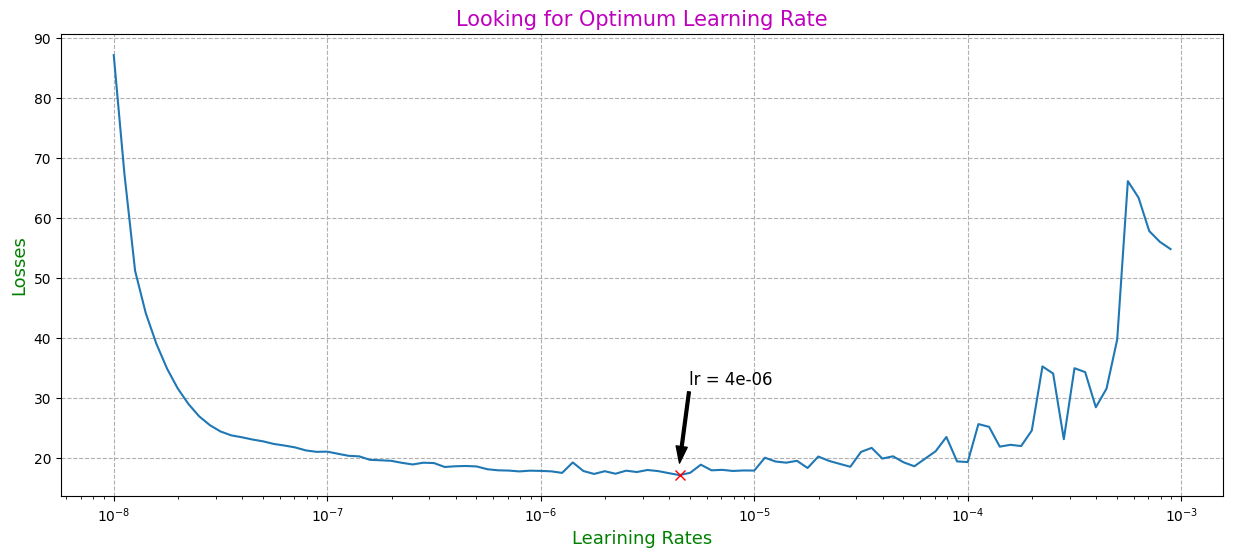

In [68]:
# Plot the output of Losses vs Learning Rates
fig = plt.figure(figsize=(15, 6))
plt.semilogx(lrs, history.history["loss"]) # Learning rates are increasing exponentially and hence for an omptimal sized plot we use semilogx plot
plt.grid(True, ls="--")
plt.plot(opt_lr,min_loss, color = 'r', marker = 'x', markersize = 7)
plt.title(f"Looking for Optimum Learning Rate", color = 'm', fontsize = 15)
plt.ylabel("Losses", fontsize = 13, color = 'g')
plt.xlabel("Learining Rates", fontsize = 13, color = 'g')
plt.annotate(f"lr = {x}", (opt_lr,min_loss+2), (opt_lr+0.05e-5, min_loss+15), arrowprops = dict(facecolor ='k', width = 2, headwidth = 8), fontsize = 12)
plt.show()

In [69]:
# Using the same steps to build the model but now with the optimal learning rate to train it
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.models.Sequential([
  tf.keras.layers.Conv1D(filters=132, kernel_size=4,strides=1, padding="causal", activation="relu",input_shape=[None, 1]),
  tf.keras.layers.LSTM(256, return_sequences=True),
  tf.keras.layers.LSTM(132, return_sequences=False),
  tf.keras.layers.Dense(80, activation="relu"),
  tf.keras.layers.Dense(10, activation="relu"),
  tf.keras.layers.Dense(1),
  tf.keras.layers.Lambda(lambda x: x * 400)
])

optimizer = tf.keras.optimizers.SGD(learning_rate=opt_lr, momentum=momentum_sgd)
model.compile(loss=tf.keras.losses.Huber(delta),
              optimizer=optimizer,
              metrics=["mae"])

history = model.fit(train_set,epochs=train_epochs)

Epoch 1/200
21/21 [==============================] - 20s 665ms/step - loss: 60.1122 - mae: 60.6083
Epoch 2/200
21/21 [==============================] - 19s 901ms/step - loss: 23.1027 - mae: 23.5971
Epoch 3/200
21/21 [==============================] - 15s 728ms/step - loss: 20.6533 - mae: 21.1478
Epoch 4/200
21/21 [==============================] - 19s 902ms/step - loss: 19.2760 - mae: 19.7683
Epoch 5/200
21/21 [==============================] - 26s 1s/step - loss: 18.6129 - mae: 19.1072
Epoch 6/200
21/21 [==============================] - 17s 783ms/step - loss: 18.1649 - mae: 18.6565
Epoch 7/200
21/21 [==============================] - 16s 742ms/step - loss: 17.9812 - mae: 18.4748
Epoch 8/200
21/21 [==============================] - 23s 1s/step - loss: 18.2387 - mae: 18.7318
Epoch 9/200
21/21 [==============================] - 28s 1s/step - loss: 17.7550 - mae: 18.2480
Epoch 10/200
21/21 [==============================] - 29s 1s/step - loss: 18.1913 - mae: 18.6843
Epoch 11/200
21/21 [=

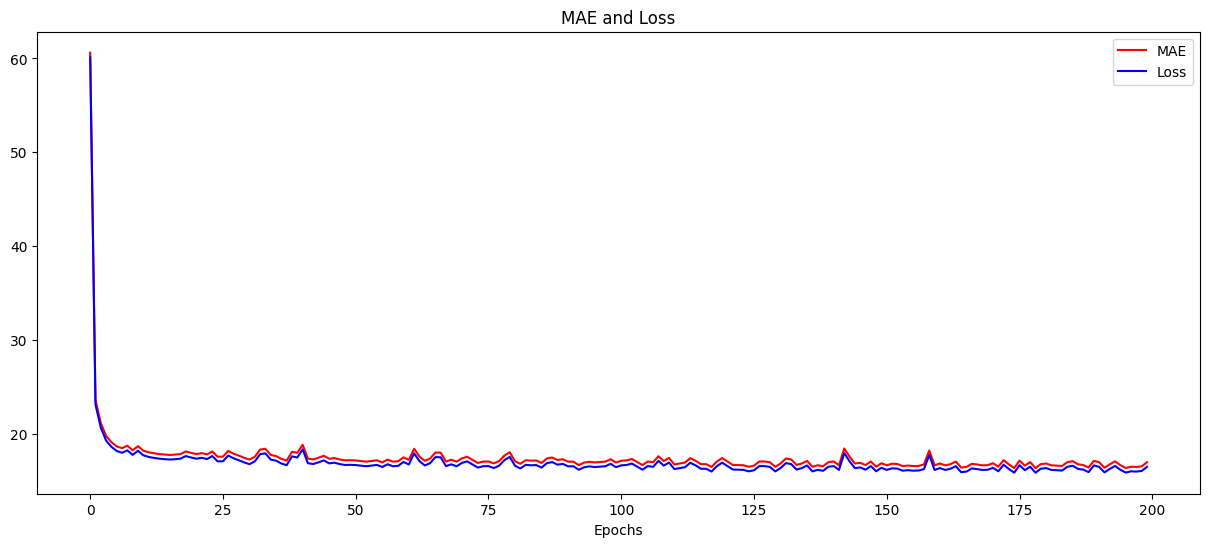

In [70]:
# Fetch the MAE and Huber Loss from the history
mae=history.history['mae']
loss=history.history['loss']

# Plot MAE and Huber Loss
fig = plt.figure(figsize=(15, 6))
plt.plot(mae, 'r')
plt.plot(loss, 'b')
plt.title('MAE and Loss')
plt.xlabel("Epochs")
plt.legend(["MAE", "Loss"])

23/23 [==============================] - 11s 355ms/step


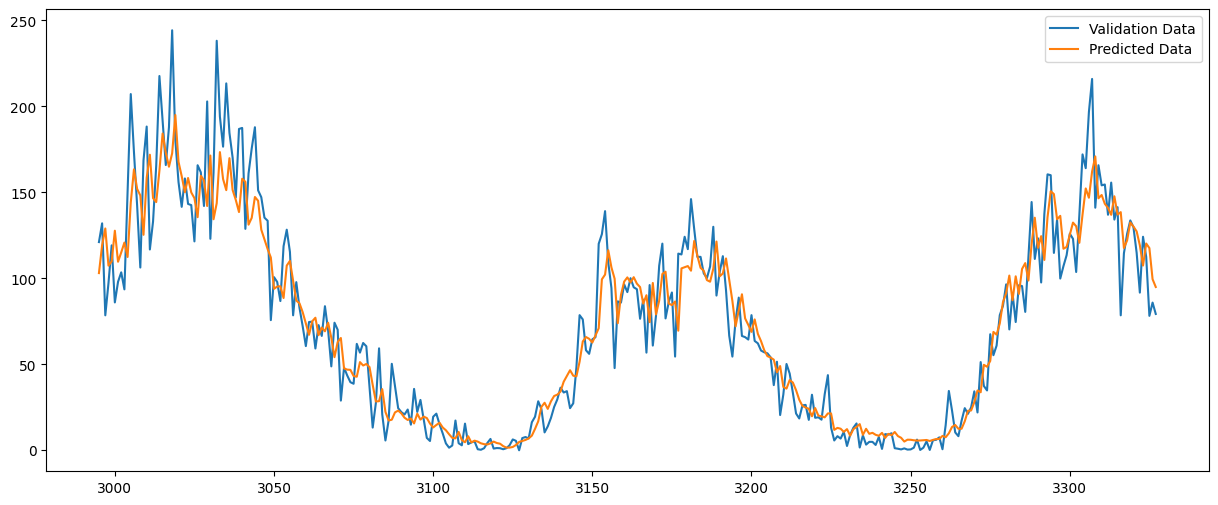

In [71]:
# Call the model_forecast here and display the plots of validation and prediction
rnn_forecast = model_forecast(model, series[:, np.newaxis], window_size)
rnn_forecast = rnn_forecast[split_time - window_size:-1, 0]  # rnn_forecast[-328:-1, 0]

# Plots
plt.figure(figsize=(15, 6))
plt.plot(time_valid, x_valid)
plt.plot(time_valid, rnn_forecast)
plt.title("")
plt.legend(["Validation Data", "Predicted Data"])
plt.show()

In [72]:
# Validation MAE
val_mae=tf.keras.metrics.mae(x_valid, rnn_forecast).numpy()
print(f"MAE on the validation data:- {val_mae}")

MAE on the validation data:- 13.658303260803223


## 结果展示

In [73]:
print(np.unique(y_pred_2024_2026))   # 如果只有一个值，说明模型预测恒定

[69.249504]


23/23 [==============================] - 5s 195ms/step


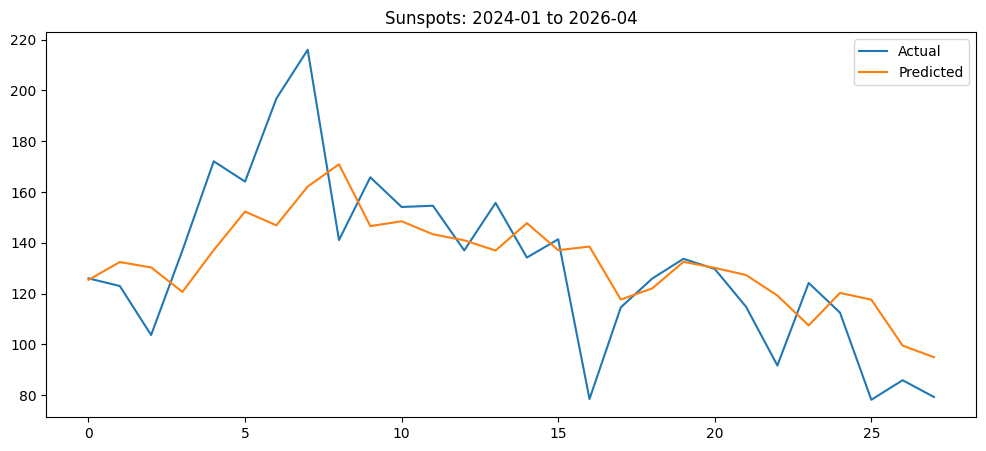

MAE (2024-2026): 18.2787
MSE (2024-2026): 595.4198


In [75]:
# 确保模型已经训练好
# 对整个序列进行预测（而不是仅验证集）
full_forecast = model_forecast(model, series[:, np.newaxis], window_size)   # shape: (len(series)-window_size, 1)
full_forecast = full_forecast[:, 0]   # 变成一维

# 计算原始数据中 2024-01 和 2026-04 的索引
data['date'] = pd.to_datetime(data[['year', 'month']].assign(day=1))
start_date = pd.Timestamp('2024-01-01')
end_date   = pd.Timestamp('2026-04-01')
start_idx = data[data['date'] == start_date].index[0]
end_idx   = data[data['date'] == end_date].index[0]

# 预测值的索引偏移：预测值对应预测从第 window_size 个点开始
# 原始索引 i 对应的预测值位于 full_forecast[i - window_size]
forecast_start = start_idx - window_size
forecast_end   = end_idx - window_size

# 检查索引是否有效
if forecast_start < 0 or forecast_end >= len(full_forecast):
    raise ValueError(f"索引超出范围: forecast_start={forecast_start}, forecast_end={forecast_end}, full_forecast长度={len(full_forecast)}")

y_true_2024_2026 = data['sunspot_number'].iloc[start_idx:end_idx+1].values
y_pred_2024_2026 = full_forecast[forecast_start:forecast_end+1]

# 可视化
plt.figure(figsize=(12,5))
plt.plot(y_true_2024_2026, label='Actual')
plt.plot(y_pred_2024_2026, label='Predicted')
plt.legend()
plt.title('Sunspots: 2024-01 to 2026-04')
plt.show()

# 计算标量 MAE 和 MSE
mae_scalar = np.mean(np.abs(y_true_2024_2026 - y_pred_2024_2026))
mse_scalar = np.mean((y_true_2024_2026 - y_pred_2024_2026) ** 2)
print(f"MAE (2024-2026): {mae_scalar:.4f}")
print(f"MSE (2024-2026): {mse_scalar:.4f}")

In [76]:
mae_scalar = tf.keras.metrics.mae(y_true_2024_2026, y_pred_2024_2026).numpy().mean()
print(mae_scalar)
mse_scalar = tf.keras.metrics.mse(y_true_2024_2026, y_pred_2024_2026).numpy().mean()
print(mse_scalar)

18.27872
595.4198
